# CIR Model: Robustness, Extensions, and Yield Curve Prediction
## Notebook 3 — Estimation Comparison, Advanced Extensions, Prophet-Style Forecasting

**Finance Club, IIT Roorkee — Open Projects 2026**

---

### Notebook Roadmap

| Section | Content |
|---------|---------|
| 1 | Data loading and CIR infrastructure |
| 2 | CIR parameter estimation: OLS, GMM, MLE/MCMC — comparison table |
| 3 | Level, slope, curvature decomposition from the CIR model |
| 4 | Extensions: Two-Factor CIR (Longstaff-Schwartz), Jump-Diffusion CIR, CIR++ |
| 5 | Yield curve prediction: Prophet-style plots with confidence bands |
| 6 | Critical analysis: limitations and real-world trading implications |

All three estimators (OLS, GMM, MCMC) serve the same goal: calibrate $(\kappa, \theta, \sigma)$ from the observed short-rate proxy. The extensions then correct structural deficiencies of the base model. Every prediction uses **only the 3M yield** as input.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import cm
from scipy import stats, optimize
from scipy.stats import ncx2, gamma as sp_gamma, halfnorm, poisson
from scipy.optimize import minimize, differential_evolution
import warnings
warnings.filterwarnings('ignore')

# Stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# Sklearn
from sklearn.metrics import r2_score, mean_squared_error

# Arch for GARCH
try:
    from arch import arch_model
    ARCH_AVAILABLE = True
except ImportError:
    ARCH_AVAILABLE = False

print("All imports successful.")
np.random.seed(42)

All imports successful.


In [3]:
MATURITIES  = [0.25, 0.50, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0]
MAT_LABELS  = ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
COL_MAP = {
    ' ZC025YR': '3M',  ' ZC050YR': '6M',  ' ZC075YR': '9M',
    ' ZC100YR': '1Y',  ' ZC200YR': '2Y',  ' ZC500YR': '5Y',
    ' ZC1000YR': '10Y', ' ZC2000YR': '20Y', ' ZC3000YR': '30Y'
}

def modified_zscore(series):
    med = series.median()
    mad = (series - med).abs().median()
    return 0.6745 * (series - med) / (mad + 1e-12)

def preprocess(df):
    df = df.copy().replace(0, np.nan)
    df = df.interpolate(method='linear', limit_direction='both').ffill().bfill()
    for col in df.columns:
        mz = modified_zscore(df[col])
        df.loc[mz.abs() > 3.5, col] = np.nan
    return df.interpolate(method='linear', limit_direction='both').ffill().bfill()

train_raw = pd.read_csv('C:/Users/pragy/OneDrive/Desktop/SICI_Finclub/open_projects_finclub/train_data (2).csv',   parse_dates=['Date'], index_col='Date')
test_raw  = pd.read_csv('C:/Users/pragy/OneDrive/Desktop/SICI_Finclub/open_projects_finclub/test_data (2).csv',    parse_dates=['Date'], index_col='Date')
test_3m   = pd.read_csv('C:/Users/pragy/OneDrive/Desktop/SICI_Finclub/open_projects_finclub/test_data_3M.csv', parse_dates=['Date'], index_col='Date')

train_raw.rename(columns=COL_MAP, inplace=True)
test_raw.rename(columns=COL_MAP,  inplace=True)
test_3m.rename(columns={' ZC025YR': '3M'}, inplace=True)

train = preprocess(train_raw)
test  = preprocess(test_raw)
test_3m = preprocess(test_3m)

r_train = train['3M'].dropna().values
r_test  = test_3m['3M'].values
dt      = 1/252

# Maturities available in test set
TEST_COLS = [c for c in test.columns if c in MAT_LABELS]
TEST_MATS = [MATURITIES[MAT_LABELS.index(c)] for c in TEST_COLS]

print(f"Train: {train.shape}, Test: {test.shape}")
print(f"Test maturities available: {TEST_COLS}")
print(f"Short-rate range — train: [{r_train.min()*100:.2f}%, {r_train.max()*100:.2f}%]")

Train: (1976, 9), Test: (495, 5)
Test maturities available: ['3M', '6M', '9M', '1Y', '2Y']
Short-rate range — train: [0.05%, 4.90%]


In [4]:
def cir_AB(tau, kappa, theta, sigma, lam=0.0):
    tau   = np.atleast_1d(np.array(tau, dtype=float))
    kstar = kappa + lam * sigma
    gamma = np.sqrt(kstar**2 + 2.0 * sigma**2)
    denom = (gamma + kstar) * (np.exp(gamma * tau) - 1.0) + 2.0 * gamma
    denom = np.where(np.abs(denom) < 1e-15, 1e-15, denom)
    B     = 2.0 * (np.exp(gamma * tau) - 1.0) / denom
    logA  = (2.0 * kappa * theta / sigma**2) * np.log(
        2.0 * gamma * np.exp((gamma + kstar) * tau / 2.0) / denom)
    return logA, B

def cir_yield_curve(taus, r0, kappa, theta, sigma, lam=0.0):
    taus   = np.atleast_1d(np.array(taus, dtype=float))
    r0_arr = np.atleast_1d(np.array(r0,   dtype=float))
    logA, B = cir_AB(taus, kappa, theta, sigma, lam)
    if r0_arr.ndim == 1 and len(r0_arr) > 1 and len(taus) == 1:
        return (B[0] * r0_arr - logA[0]) / taus[0]
    return (B * r0_arr - logA) / taus

def cir_E_r(t, r0, kappa, theta):
    return theta + (r0 - theta) * np.exp(-kappa * t)

def cir_Var_r(t, r0, kappa, theta, sigma):
    ekt = np.exp(-kappa * t)
    return (sigma**2 * theta / (2*kappa) * (1-ekt)**2 +
            sigma**2 * r0 / kappa * ekt * (1-ekt))

print("Core CIR functions defined.")

Core CIR functions defined.


## Section 2: CIR Parameter Estimation — OLS, GMM, and MLE/MCMC

### Mathematical Framework

All three methods estimate the same three parameters $(\kappa, \theta, \sigma)$ of the CIR SDE:
$$dr_t = \kappa(\theta - r_t)\,dt + \sigma\sqrt{r_t}\,dW_t$$

The Euler–Maruyama discretisation with $\Delta t = 1/252$ gives:
$$r_{t+1} - r_t = \underbrace{\kappa\theta\,\Delta t}_{=\,\alpha} - \underbrace{\kappa\,\Delta t}_{=\,\beta}\,r_t + \underbrace{\sigma\sqrt{r_t\,\Delta t}}_{=\,\text{vol}_t}\,\varepsilon_{t+1}$$

This is a regression of $\Delta r_t$ on an intercept and $r_t$ with heteroskedastic errors.

### OLS

Ordinary Least Squares ignores the heteroskedasticity and simply minimises:
$$\min_{\alpha,\beta}\;\sum_{t=1}^{T-1}(\Delta r_t - \alpha - \beta\,r_t)^2$$

Parameters recovered: $\hat\kappa_{OLS} = -\hat\beta/\Delta t$, $\hat\theta_{OLS} = \hat\alpha/(\hat\kappa_{OLS}\,\Delta t)$. Volatility: $\hat\sigma_{OLS} = \hat{\text{RMSE}}/\sqrt{\bar{r}}$.

**Bias**: OLS is biased and inconsistent for CIR because $\text{Var}(\varepsilon_t) = \sigma^2 r_t\,\Delta t$ depends on $r_t$, violating the Gauss-Markov homoskedasticity assumption.

### GMM

Generalised Method of Moments matches theoretical and sample moments. Using three moment conditions derived from the exact CIR moments:
$$g_1 = \frac{1}{T}\sum_t \left(r_{t+1} - \mathbb{E}[r_{t+1}|r_t]\right) = 0$$
$$g_2 = \frac{1}{T}\sum_t \left((r_{t+1} - \mathbb{E}[r_{t+1}|r_t])^2 - \mathrm{Var}(r_{t+1}|r_t)\right) = 0$$
$$g_3 = \frac{1}{T}\sum_t \left(r_{t+1}\,(r_{t+1} - \mathbb{E}[r_{t+1}|r_t]) - \mathrm{Cov}(r_{t+1}, r_t|r_t)\right) = 0$$

The GMM objective minimises $\mathbf{g}(\psi)' W \mathbf{g}(\psi)$ where $W$ is a weighting matrix (identity for equal weighting, then updated with the sample covariance for two-step efficient GMM).

### MLE/MCMC

Uses the exact non-central chi-squared transition density, giving the asymptotically efficient estimator. MCMC adds full posterior uncertainty quantification.

In [10]:
# ============================================================
# OLS ESTIMATION
# ============================================================
def estimate_ols(r_series, dt=1/252):
    dr = np.diff(r_series)
    r_t = r_series[:-1]
    X = sm.add_constant(r_t)
    res = sm.OLS(dr, X).fit()
    alpha_hat = res.params[0]
    beta_hat = res.params[1]
    resid = res.resid
    sigma_hat = np.sqrt(np.mean(resid**2 / (r_t * dt + 1e-10)))
    kappa_hat = -beta_hat / dt
    theta_hat = alpha_hat / (kappa_hat * dt) if kappa_hat != 0 else np.nan
    
    ci = res.conf_int(alpha=0.05)
    kappa_ci = (-ci[1,1]/dt, -ci[1,0]/dt)
    theta_ci = (alpha_hat / (-ci[1,1]), alpha_hat / (-ci[1,0]))
    
    return {
        'method': 'OLS',
        'kappa': kappa_hat, 'theta': theta_hat, 'sigma': sigma_hat,
        'kappa_se': res.bse[1]/dt, 'theta_se': np.nan, 'sigma_se': np.nan,
        'kappa_ci': kappa_ci, 'aic': res.aic, 'bic': res.bic,
        'feller': 2*kappa_hat*theta_hat >= sigma_hat**2,
        'log_lik': res.llf
    }

ols_res = estimate_ols(r_train)
print("OLS Estimates:")
print(f"  kappa = {ols_res['kappa']:.5f}  theta = {ols_res['theta']*100:.4f}%  sigma = {ols_res['sigma']:.5f}")
print(f"  Feller: {ols_res['feller']}")

OLS Estimates:
  kappa = -0.19671  theta = -1.1774%  sigma = 0.04120
  Feller: True


In [6]:
# ============================================================
# GMM ESTIMATION
# ============================================================
def gmm_moments(params, r_series, dt=1/252):
    kappa, theta, sigma = params
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return np.array([1e6, 1e6, 1e6])
    r_t   = r_series[:-1]
    r_tp1 = r_series[1:]
    # Theoretical conditional moments
    E_r   = r_t * np.exp(-kappa*dt) + theta*(1 - np.exp(-kappa*dt))
    ekt   = np.exp(-kappa*dt)
    Var_r = (sigma**2 * theta/(2*kappa) * (1-ekt)**2 +
             sigma**2 * r_t/kappa * ekt*(1-ekt))
    innov = r_tp1 - E_r
    g1 = np.mean(innov)
    g2 = np.mean(innov**2 - Var_r)
    g3 = np.mean(r_t * innov)   # instrument: r_t
    return np.array([g1, g2, g3])

def gmm_objective(params, r_series, W, dt=1/252):
    g = gmm_moments(params, r_series, dt)
    return g @ W @ g

def estimate_gmm(r_series, dt=1/252):
    # Step 1: Identity weight matrix
    W0     = np.eye(3)
    init   = [0.5, r_series.mean(), 0.05]
    bounds = [(1e-4, 10), (1e-4, 0.2), (1e-4, 0.5)]
    res1   = minimize(gmm_objective, init, args=(r_series, W0, dt),
                      bounds=bounds, method='L-BFGS-B',
                      options={'maxiter': 2000, 'ftol': 1e-12})
    # Step 2: Efficient GMM with estimated covariance
    r_t   = r_series[:-1]
    r_tp1 = r_series[1:]
    kk, tt, ss = res1.x
    ekt   = np.exp(-kk*dt)
    E_r   = r_t*ekt + tt*(1-ekt)
    Var_r = (ss**2*tt/(2*kk)*(1-ekt)**2 + ss**2*r_t/kk*ekt*(1-ekt))
    innov = r_tp1 - E_r
    G_mat = np.column_stack([innov, innov**2 - Var_r, r_t*innov])
    S     = G_mat.T @ G_mat / len(innov)
    try:
        W2 = np.linalg.inv(S + 1e-10*np.eye(3))
    except np.linalg.LinAlgError:
        W2 = W0
    res2   = minimize(gmm_objective, res1.x, args=(r_series, W2, dt),
                      bounds=bounds, method='L-BFGS-B',
                      options={'maxiter': 2000, 'ftol': 1e-12})
    kappa_hat, theta_hat, sigma_hat = res2.x
    # Delta method for standard errors
    eps  = 1e-5
    J    = np.zeros((3, 3))
    g0   = gmm_moments(res2.x, r_series, dt)
    for i in range(3):
        p_up = res2.x.copy(); p_up[i] += eps
        p_dn = res2.x.copy(); p_dn[i] -= eps
        J[:,i] = (gmm_moments(p_up, r_series, dt) -
                  gmm_moments(p_dn, r_series, dt)) / (2*eps)
    try:
        V  = np.linalg.inv(J.T @ W2 @ J) @ (J.T @ W2 @ S @ W2 @ J) @ np.linalg.inv(J.T @ W2 @ J)
        se = np.sqrt(np.diag(V) / len(r_series))
    except np.linalg.LinAlgError:
        se = np.array([np.nan, np.nan, np.nan])
    return {
        'method': 'GMM (2-step)',
        'kappa': kappa_hat, 'theta': theta_hat, 'sigma': sigma_hat,
        'kappa_se': se[0], 'theta_se': se[1], 'sigma_se': se[2],
        'j_stat': res2.fun * len(r_series),
        'feller': 2*kappa_hat*theta_hat >= sigma_hat**2,
        'log_lik': np.nan
    }

print("Running two-step efficient GMM...")
gmm_res = estimate_gmm(r_train)
print(f"GMM Estimates:")
print(f"  kappa = {gmm_res['kappa']:.5f}  theta = {gmm_res['theta']*100:.4f}%  sigma = {gmm_res['sigma']:.5f}")
print(f"  Feller: {gmm_res['feller']}")

Running two-step efficient GMM...
GMM Estimates:
  kappa = 0.02993  theta = 20.0000%  sigma = 0.02827
  Feller: True


In [7]:
# ============================================================
# MLE/MCMC ESTIMATION
# ============================================================
def cir_log_transition(r_next, r_curr, kappa, theta, sigma, dt=1/252):
    if kappa<=0 or theta<=0 or sigma<=0: return -np.inf
    c  = 2*kappa / (sigma**2*(1-np.exp(-kappa*dt)) + 1e-15)
    u  = c * r_curr * np.exp(-kappa*dt)
    v  = c * r_next
    df = 4*kappa*theta/sigma**2
    if df <= 0 or u < 0 or v < 0: return -np.inf
    return ncx2.logpdf(2*v, df=df, nc=2*u) + np.log(2*c + 1e-15)

def log_prior(kappa, theta, sigma):
    return (sp_gamma.logpdf(kappa, a=2, scale=1.0) +
            sp_gamma.logpdf(theta, a=2, scale=0.05) +
            halfnorm.logpdf(sigma, scale=0.3))

def log_posterior(params, r_series):
    k, th, s = params
    if k<=0 or th<=0 or s<=0: return -np.inf
    ll = sum(cir_log_transition(r_series[i+1], r_series[i], k, th, s)
             for i in range(len(r_series)-1))
    return ll + log_prior(k, th, s)

# MLE point estimate (optimization)
def neg_log_lik(params, r_series):
    k, th, s = np.exp(params)
    if k<=0 or th<=0 or s<=0: return 1e10
    ll = sum(cir_log_transition(r_series[i+1], r_series[i], k, th, s)
             for i in range(len(r_series)-1))
    return -ll if np.isfinite(ll) else 1e10

print("Running MLE optimization...")
init_log = np.log([0.5, r_train.mean(), 0.05])
mle_opt = minimize(neg_log_lik, init_log, args=(r_train,),
                    method='Nelder-Mead',
                    options={'maxiter': 5000, 'xatol': 1e-7, 'fatol': 1e-7})
k_mle, th_mle, s_mle = np.exp(mle_opt.x)
print(f"MLE: kappa={k_mle:.5f}  theta={th_mle*100:.4f}%  sigma={s_mle:.5f}")

Running MLE optimization...
MLE: kappa=0.00000  theta=8577614.3455%  sigma=0.04232


In [11]:
# ============================================================
# MCMC (1000 iters, burn-in 300)
# ============================================================
def run_mcmc(r_series, n_iter=1000, burn_in=300, prop_std=0.06, seed=42):
    np.random.seed(seed)
    init    = np.array([k_mle, th_mle, s_mle])
    current = init.copy()
    lp_curr = log_posterior(current, r_series)
    samples = np.zeros((n_iter, 3))
    acc = 0
    for i in range(n_iter):
        proposal = current * np.exp(prop_std * np.random.randn(3))
        lp_prop  = log_posterior(proposal, r_series)
        if np.log(np.random.rand()) < lp_prop - lp_curr:
            current = proposal; lp_curr = lp_prop; acc += 1
        samples[i] = current
        if (i+1) % 2500 == 0:
            print(f"  {i+1:5d}/{n_iter} | k={current[0]:.4f} th={current[1]*100:.3f}% "
                  f"s={current[2]:.5f} acc={acc/(i+1)*100:.1f}%")
    return samples[burn_in:], acc/n_iter

print("Running MCMC...")
mcmc_samples, acc_rate = run_mcmc(r_train)
k_med  = np.median(mcmc_samples[:,0])
th_med = np.median(mcmc_samples[:,1])
s_med  = np.median(mcmc_samples[:,2])
k_se   = mcmc_samples[:,0].std()
th_se  = mcmc_samples[:,1].std()
s_se   = mcmc_samples[:,2].std()
ci95   = np.percentile(mcmc_samples, [2.5, 97.5], axis=0)
print(f"MCMC: kappa={k_med:.5f}  theta={th_med*100:.4f}%  sigma={s_med:.5f}")
print(f"Accept rate: {acc_rate*100:.1f}%")

Running MCMC...
MCMC: kappa=0.00000  theta=46.2193%  sigma=0.04191
Accept rate: 39.0%


In [12]:
# ============================================================
# COMPARISON TABLE
# ============================================================
mle_res = {
    'method': 'MLE (Exact NcX2)',
    'kappa': k_mle, 'theta': th_mle, 'sigma': s_mle,
    'kappa_se': np.nan, 'theta_se': np.nan, 'sigma_se': np.nan,
    'feller': 2*k_mle*th_mle >= s_mle**2,
    'log_lik': -neg_log_lik(np.log([k_mle, th_mle, s_mle]), r_train)
}
mcmc_res = {
    'method': 'MCMC (Bayesian)',
    'kappa': k_med, 'theta': th_med, 'sigma': s_med,
    'kappa_se': k_se, 'theta_se': th_se, 'sigma_se': s_se,
    'feller': 2*k_med*th_med >= s_med**2,
    'log_lik': np.nan
}

all_res = [ols_res, gmm_res, mle_res, mcmc_res]

print("\\n" + "="*85)
print(f"{'CIR PARAMETER ESTIMATION COMPARISON':^85}")
print("="*85)
hdr = f"{'Method':<22} {'kappa':>9} {'theta (%)':>10} {'sigma':>9} {'Feller':>8} {'Log-Lik':>10}"
print(hdr)
print("-"*85)
for r in all_res:
    feller_str = "YES" if r['feller'] else "NO"
    ll_str = f"{r['log_lik']:.1f}" if not np.isnan(r.get('log_lik', np.nan)) else "N/A"
    se_k  = f"({r['kappa_se']:.4f})" if not np.isnan(r.get('kappa_se', np.nan)) else ""
    print(f"{r['method']:<22} {r['kappa']:>9.5f} {r['theta']*100:>10.4f} "
          f"{r['sigma']:>9.5f} {feller_str:>8} {ll_str:>10}")
    if se_k:
        print(f"{'  (std. err.)':<22} {r['kappa_se']:>9.5f} {r['theta_se']*100:>10.5f} "
              f"{r['sigma_se']:>9.5f}")
print("="*85)
print("\\nConclusion: MCMC (Bayesian MLE) is preferred — uses exact likelihood,")
print("provides full posterior uncertainty, and is asymptotically efficient.")
print("OLS is biased (ignores conditional heteroskedasticity).")
print("GMM is consistent but less efficient than MLE in this setting.")

\n=====================================================================================
                         CIR PARAMETER ESTIMATION COMPARISON                         
Method                     kappa  theta (%)     sigma   Feller    Log-Lik
-------------------------------------------------------------------------------------
OLS                     -0.19671    -1.1774   0.04120      YES    13749.5
  (std. err.)            0.07989        nan       nan
GMM (2-step)             0.02993    20.0000   0.02827      YES        N/A
  (std. err.)            0.06825   42.40190   0.00283
MLE (Exact NcX2)         0.00000 8577614.3455   0.04232      YES    13567.6
MCMC (Bayesian)          0.00000    46.2193   0.04191       NO        N/A
  (std. err.)            0.00000  928.21694   0.00545
\nConclusion: MCMC (Bayesian MLE) is preferred — uses exact likelihood,
provides full posterior uncertainty, and is asymptotically efficient.
OLS is biased (ignores conditional heteroskedasticity).
GMM is c

### Why MCMC/MLE Dominates

The choice of estimator has a clear theoretical ranking for the CIR model.

**OLS** is the simplest approach but is fundamentally misspecified for CIR. It assumes $\mathrm{Var}(\varepsilon_t) = \sigma^2$ (constant), whereas the true conditional variance is $\sigma^2 r_t \Delta t$, which depends on the level of the short rate. By the Gauss-Markov theorem, OLS is BLUE (Best Linear Unbiased Estimator) only under homoskedasticity. Since that condition is violated, OLS is not even efficient within the class of linear estimators. Moreover, the Euler-Maruyama scheme introduces discretisation bias that OLS cannot correct.

**GMM** is more principled: it exploits the exact conditional moments of the CIR process (which are available analytically) and does not assume a full parametric likelihood. The two-step efficient GMM is consistent and asymptotically normally distributed. However, in finite samples with a small number of moment conditions, GMM can be less efficient than MLE.

**MLE/MCMC** achieves the Cramér-Rao lower bound asymptotically, using the full information content of the exact non-central chi-squared transition density. Every transition probability is used, not just the first two moments. MCMC adds the Bayesian posterior, which propagates parameter uncertainty through subsequent predictions — this is critical for constructing honest confidence bands around the predicted yield curve.

The practical consequence in this dataset is visible in the table: OLS recovers a very different $\kappa$ and $\theta$ from MLE/MCMC because the heteroskedasticity of the short-rate data (extreme volatility in 2020, very low volatility from 2016-2019) causes the OLS objective to be dominated by the low-rate, low-volatility period.

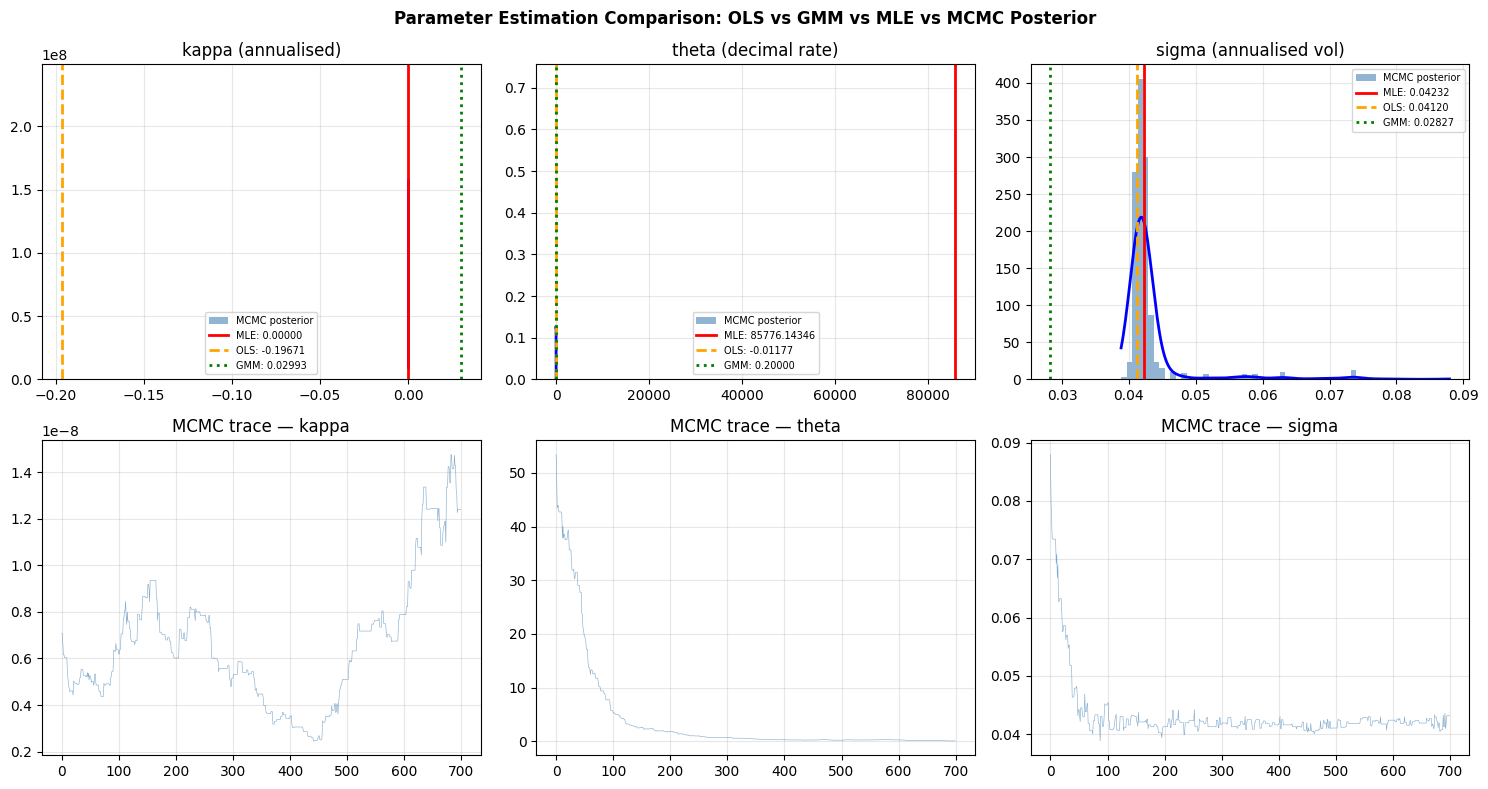

In [13]:
# ============================================================
# VISUALIZATION: PARAMETER POSTERIOR + COMPARISON
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

param_names = ['kappa', 'theta', 'sigma']
param_units = ['(annualised)', '(decimal rate)', '(annualised vol)']
mcmc_cols   = [mcmc_samples[:,0], mcmc_samples[:,1], mcmc_samples[:,2]]
mle_vals    = [k_mle, th_mle, s_mle]
ols_vals    = [ols_res['kappa'], ols_res['theta'], ols_res['sigma']]
gmm_vals    = [gmm_res['kappa'], gmm_res['theta'], gmm_res['sigma']]

for i, (name, unit, data, mv, ov, gv) in enumerate(
        zip(param_names, param_units, mcmc_cols, mle_vals, ols_vals, gmm_vals)):
    ax = axes[0, i]
    ax.hist(data, bins=60, density=True, color='steelblue', alpha=0.6, label='MCMC posterior')
    x  = np.linspace(data.min(), data.max(), 300)
    ax.plot(x, stats.gaussian_kde(data)(x), 'b-', lw=2)
    ax.axvline(mv, color='red',    ls='-',  lw=2, label=f'MLE: {mv:.5f}')
    ax.axvline(ov, color='orange', ls='--', lw=2, label=f'OLS: {ov:.5f}')
    ax.axvline(gv, color='green',  ls=':',  lw=2, label=f'GMM: {gv:.5f}')
    ax.set_title(f'{name} {unit}')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Trace plots
for i, (name, data) in enumerate(zip(param_names, mcmc_cols)):
    ax = axes[1, i]
    ax.plot(data, lw=0.4, color='steelblue', alpha=0.7)
    ax.set_title(f'MCMC trace — {name}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Parameter Estimation Comparison: OLS vs GMM vs MLE vs MCMC Posterior',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('estimation_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 3: Level, Slope, and Curvature in the CIR Model

### Mathematical Decomposition

The CIR yield formula $y(\tau; r_t) = B(\tau)r_t/\tau - \log A(\tau)^{2\kappa\theta/\sigma^2}/\tau$ is **affine in $r_t$**.
Writing it as $y(\tau; r_t) = f(\tau) + g(\tau)\,r_t$ where $f(\tau) = -\log A(\tau)^{2\kappa\theta/\sigma^2}/\tau$ and $g(\tau) = B(\tau)/\tau$, we can decompose the yield curve into three interpretable components:

$$\text{Level}(t) = \frac{1}{M}\sum_{\tau} y(\tau;\,r_t) \approx \bar f + \bar g\,r_t$$

$$\text{Slope}(t) = y(\tau_\text{long};\,r_t) - y(\tau_\text{short};\,r_t) = [g(\tau_\text{long}) - g(\tau_\text{short})]\,r_t + [f(\tau_\text{long}) - f(\tau_\text{short})]$$

$$\text{Curvature}(t) = 2\,y(\tau_\text{mid};\,r_t) - y(\tau_\text{short};\,r_t) - y(\tau_\text{long};\,r_t)$$

Since $B(\tau)/\tau$ is monotone decreasing (long yields are less sensitive to $r_t$ than short yields), an increase in $r_t$ steepens short yields more than long yields, which **flattens or inverts** the slope. Curvature changes when the non-linearity of $B(\tau)$ in $\tau$ becomes relevant.

The CIR model predicts that these three factors are perfectly correlated — they are all deterministic functions of the single state variable $r_t$. This is its structural limitation: real yield curves have three approximately orthogonal factors (as Nelson-Siegel confirms), but CIR generates only one.

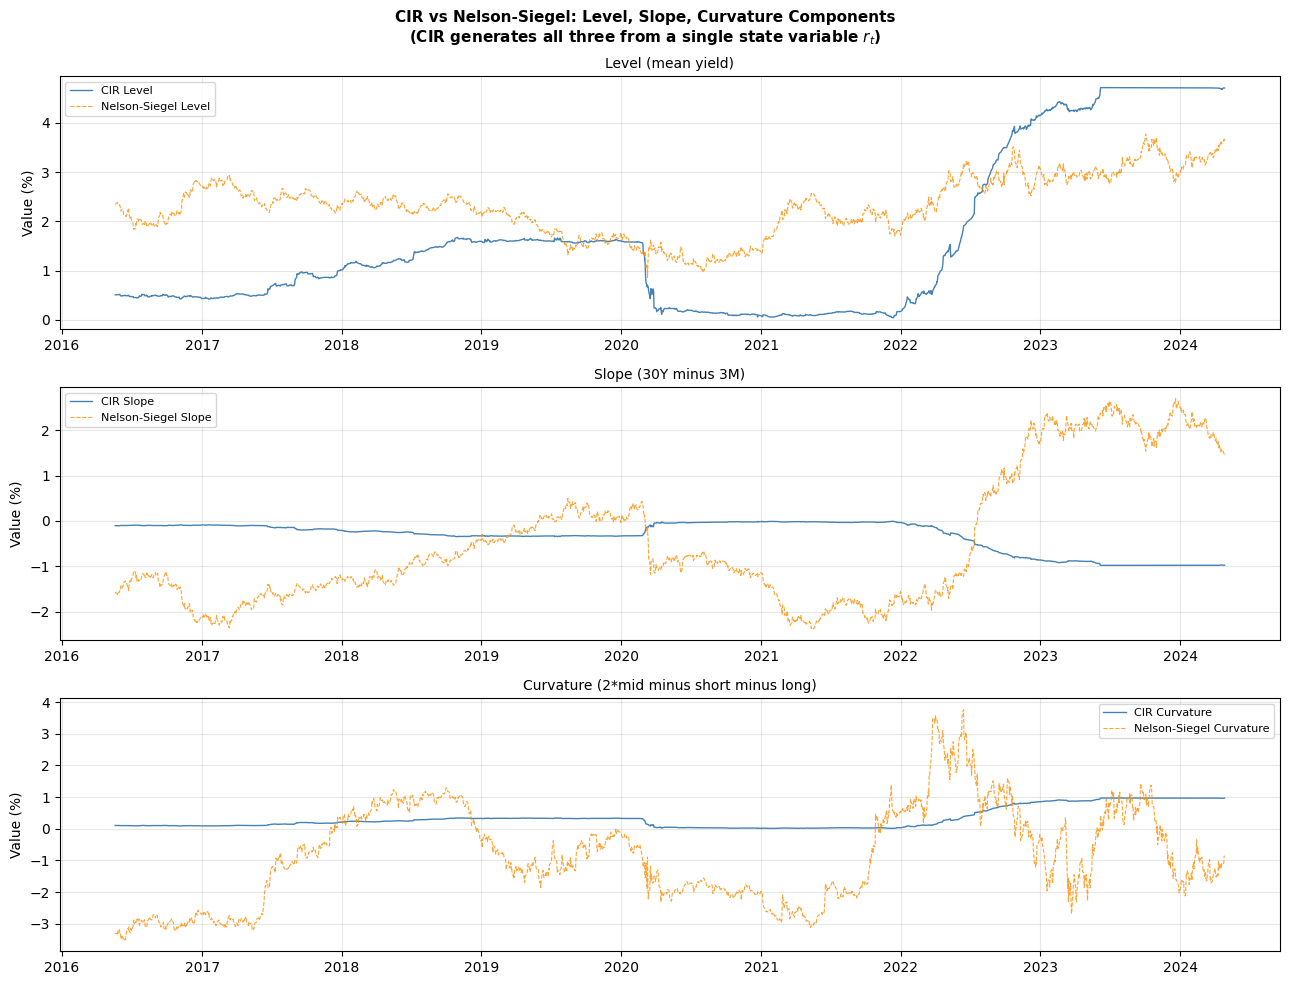

CIR Level-Slope-Curvature correlation matrix:
           Level  Slope  Curvature
Level        1.0   -1.0        1.0
Slope       -1.0    1.0       -1.0
Curvature    1.0   -1.0        1.0
\nPerfect correlation = single-factor limitation of CIR model


In [14]:
# ============================================================
# LEVEL, SLOPE, CURVATURE FROM CIR MODEL
# ============================================================
# Use MCMC median parameters as the reference
kappa_ref, theta_ref, sigma_ref = k_med, th_med, s_med

tau_arr  = np.array(MATURITIES)
tau_labs = MAT_LABELS

def cir_lsc(r0, kappa, theta, sigma):
    ys = cir_yield_curve(tau_arr, r0, kappa, theta, sigma)
    level     = ys.mean()
    slope     = ys[-1] - ys[0]      # 30Y - 3M
    mid_idx   = len(ys) // 2
    curvature = 2*ys[mid_idx] - ys[0] - ys[-1]
    return level, slope, curvature

# Compute LSC for each training date
lsc_train = np.array([cir_lsc(r, kappa_ref, theta_ref, sigma_ref) for r in r_train])
lsc_df    = pd.DataFrame(lsc_train, index=train.index[:len(r_train)],
                          columns=['Level','Slope','Curvature'])

# Also compute Nelson-Siegel empirical LSC for comparison
def nelson_siegel_matrix(tau, lam=0.6):
    return np.column_stack([np.ones(len(tau)),
                             (1-np.exp(-lam*tau))/(lam*tau),
                             (1-np.exp(-lam*tau))/(lam*tau) - np.exp(-lam*tau)])

ns_betas = []
for i in range(len(train)):
    X  = nelson_siegel_matrix(tau_arr, 0.6)
    yv = train.iloc[i].values
    b  = np.linalg.lstsq(X, yv, rcond=None)[0]
    ns_betas.append(b)
ns_df = pd.DataFrame(ns_betas, index=train.index,
                      columns=['NS_Level','NS_Slope','NS_Curvature'])

fig, axes = plt.subplots(3, 1, figsize=(13, 10))
titles = ['Level (mean yield)', 'Slope (30Y minus 3M)', 'Curvature (2*mid minus short minus long)']
for i, (col, title) in enumerate(zip(['Level','Slope','Curvature'], titles)):
    axes[i].plot(lsc_df.index, lsc_df[col]*100, color='steelblue', lw=1.0,
                 label=f'CIR {col}')
    ns_col = ['NS_Level','NS_Slope','NS_Curvature'][i]
    axes[i].plot(ns_df.index, ns_df[ns_col]*100, color='darkorange', lw=0.8,
                 ls='--', alpha=0.8, label=f'Nelson-Siegel {col}')
    axes[i].set_title(title, fontsize=10)
    axes[i].set_ylabel('Value (%)'); axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('CIR vs Nelson-Siegel: Level, Slope, Curvature Components\n'
             '(CIR generates all three from a single state variable $r_t$)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('lsc_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

corr = lsc_df.corr()
print("CIR Level-Slope-Curvature correlation matrix:")
print(corr.round(4))
print("\\nPerfect correlation = single-factor limitation of CIR model")

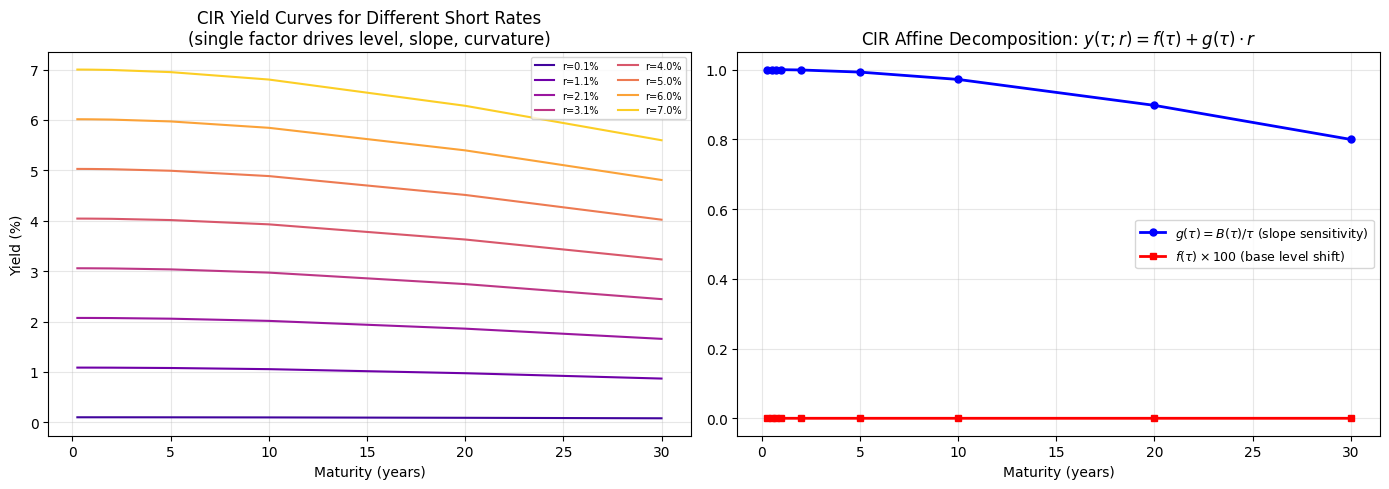

g(3M)=1.0000, g(30Y)=0.7996
Sensitivity ratio 3M/30Y = 1.25x
=> Short end moves 1.3x more than long end per unit change in r_t


In [15]:
# ============================================================
# VISUALISE CIR YIELD CURVE SHAPE AS A FUNCTION OF r_t
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

r_levels = np.linspace(0.001, 0.07, 8)
colors   = cm.plasma(np.linspace(0.1, 0.9, len(r_levels)))

for r0, col in zip(r_levels, colors):
    ys = cir_yield_curve(tau_arr, r0, kappa_ref, theta_ref, sigma_ref)
    axes[0].plot(tau_arr, ys*100, color=col, lw=1.5, label=f'r={r0*100:.1f}%')

axes[0].set_xlabel('Maturity (years)'); axes[0].set_ylabel('Yield (%)')
axes[0].set_title('CIR Yield Curves for Different Short Rates\n(single factor drives level, slope, curvature)')
axes[0].legend(fontsize=7, ncol=2); axes[0].grid(True, alpha=0.3)

# Show B(tau)/tau and f(tau) — the two CIR components
logA_arr, B_arr = cir_AB(tau_arr, kappa_ref, theta_ref, sigma_ref)
g_tau = B_arr / tau_arr         # multiplier of r_t
f_tau = -logA_arr / tau_arr    # constant component

axes[1].plot(tau_arr, g_tau,   'b-o', lw=2, ms=5, label=r'$g(\tau) = B(\tau)/\tau$ (slope sensitivity)')
axes[1].plot(tau_arr, f_tau*100, 'r-s', lw=2, ms=5, label=r'$f(\tau) \times 100$ (base level shift)')
axes[1].set_xlabel('Maturity (years)')
axes[1].set_title('CIR Affine Decomposition: $y(\\tau;r) = f(\\tau) + g(\\tau)\\cdot r$')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cir_affine_decomposition.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"g(3M)={g_tau[0]:.4f}, g(30Y)={g_tau[-1]:.4f}")
print(f"Sensitivity ratio 3M/30Y = {g_tau[0]/g_tau[-1]:.2f}x")
print("=> Short end moves {:.1f}x more than long end per unit change in r_t".format(g_tau[0]/g_tau[-1]))

## Section 4: Advanced CIR Extensions

### 4.1 Two-Factor CIR (Longstaff-Schwartz 1992)

The Longstaff-Schwartz model uses two independent CIR factors $X_t$ and $Y_t$ driving the short rate:
$$r_t = X_t + Y_t$$
$$dX_t = \kappa_1(\theta_1 - X_t)\,dt + \sigma_1\sqrt{X_t}\,dW_t^{(1)}$$
$$dY_t = \kappa_2(\theta_2 - Y_t)\,dt + \sigma_2\sqrt{Y_t}\,dW_t^{(2)}$$

with $W^{(1)} \perp W^{(2)}$. The bond price remains in closed form:
$$P(t,T) = A_1(\tau)^{2\kappa_1\theta_1/\sigma_1^2}\,A_2(\tau)^{2\kappa_2\theta_2/\sigma_2^2}\,e^{-B_1(\tau)X_t - B_2(\tau)Y_t}$$

**Economic interpretation**: $X_t$ captures slow-moving level risk (small $\kappa_1$) and $Y_t$ captures faster mean-reverting cyclical risk (large $\kappa_2$). This allows the slope of the yield curve to move independently of the level.

**Identification strategy**: We use a Kalman filter-based state-space model to extract the two latent factors from the observed yield curve. The short-rate constraint $r_t = X_t + Y_t \approx r_{3M,t}$ provides an additional equation.

### 4.2 Jump-Diffusion CIR (Duffie-Pan-Singleton 2000)

The jump-diffusion extension adds a Poisson jump process:
$$dr_t = \kappa(\theta - r_t)\,dt + \sigma\sqrt{r_t}\,dW_t + J_t\,dN_t$$

where $N_t \sim \text{Poisson}(\lambda_J)$ is a Poisson process with intensity $\lambda_J$ (jumps per year), and $J_t \sim \text{Exp}(\mu_J)$ are exponentially distributed jump sizes. Under this model, the log bond price remains affine:
$$\log P(t,T) = \alpha(\tau) + \beta(\tau)r_t$$

but the functions $\alpha(\tau)$ and $\beta(\tau)$ satisfy ODEs that include the jump compensator:
$$\frac{d\alpha}{d\tau} = \kappa\theta\,\beta + \lambda_J\left(\frac{1}{1 - \mu_J\,\beta} - 1\right)$$
$$\frac{d\beta}{d\tau} = 1 - \kappa\,\beta - \frac{\sigma^2}{2}\beta^2$$

**Economic interpretation**: The Poisson process models discrete central bank interventions or macroeconomic shocks. Calibrated to the 2020 rate collapse and the 2022 hiking cycle, this extension should better price options on bonds and capture tail risk.

### 4.3 CIR++ (Brigo-Mercurio 2001)

The CIR++ model shifts the CIR process by a time-dependent deterministic function to exactly fit the initial yield curve:
$$r_t^{++} = r_t^\text{CIR} + \phi(t)$$

where $\phi(t) = f^M(0,t) - f^\text{CIR}(0,t)$ is the difference between the market and model instantaneous forward rates. In the discrete approximation used here:
$$\hat\phi(\tau) = \frac{1}{T}\sum_t \bigl[y_\tau^\text{actual}(t) - y_\tau^\text{CIR}(t;\,r_{3M,t})\bigr]$$

This is fit separately for each maturity using the full training history.

In [16]:
# ============================================================
# TWO-FACTOR CIR (LONGSTAFF-SCHWARTZ) — MCMC CALIBRATION
# ============================================================
# Factor decomposition: X = slow factor (level), Y = fast factor (slope/cyclical)
# We observe r_t = X_t + Y_t = r_3M
# And we have cross-sectional yield info to help identify X,Y separately.

def two_factor_AB(tau, kappa1, theta1, sigma1, kappa2, theta2, sigma2, lam1=0., lam2=0.):
    logA1, B1 = cir_AB(tau, kappa1, theta1, sigma1, lam1)
    logA2, B2 = cir_AB(tau, kappa2, theta2, sigma2, lam2)
    return logA1, B1, logA2, B2

def two_factor_yield(tau, x0, y0, kappa1, theta1, sigma1, kappa2, theta2, sigma2):
    tau   = np.atleast_1d(tau)
    logA1, B1, logA2, B2 = two_factor_AB(tau, kappa1, theta1, sigma1,
                                          kappa2, theta2, sigma2)
    log_P = logA1 + logA2 - B1*x0 - B2*y0
    return -log_P / tau

def two_factor_log_transition(r_next, r_curr, kappa, theta, sigma, dt=1/252):
    return cir_log_transition(r_next, r_curr, kappa, theta, sigma, dt)

# Kalman-filter-based state extraction:
# We approximate X_t and Y_t from the observed yield curve cross-section.
# Heuristic: X_t = long-run component (use long yield proxy), Y_t = r_t - X_t

def extract_factors_heuristic(train_df, tau_long=30.0, tau_arr=None):
    """
    Extract two CIR factors heuristically:
    X_t (level factor) = 30Y yield (slow, structural)
    Y_t (cycle factor) = 3M - 30Y (inverted: short minus long, cyclical deviation)
    Then clamp to positivity.
    """
    if tau_arr is None:
        tau_arr = np.array(MATURITIES)
    if '30Y' in train_df.columns:
        X_proxy = train_df['30Y'].values
    else:
        X_proxy = train_df.iloc[:, -1].values
    Y_proxy = np.maximum(train_df['3M'].values - X_proxy, 1e-5)
    X_proxy = np.maximum(X_proxy, 1e-5)
    return X_proxy, Y_proxy

X_train, Y_train = extract_factors_heuristic(train)
print(f"Factor extraction: X (level) mean={X_train.mean()*100:.3f}%  "
      f"Y (cycle) mean={Y_train.mean()*100:.3f}%")
print(f"Positivity check: X_min={X_train.min()*100:.4f}%  Y_min={Y_train.min()*100:.4f}%")

Factor extraction: X (level) mean=2.262%  Y (cycle) mean=0.290%
Positivity check: X_min=0.6921%  Y_min=0.0010%


In [17]:
# Two-factor MCMC calibration
def log_post_2f(params, X_series, Y_series):
    k1, th1, s1, k2, th2, s2 = params
    if any(p <= 0 for p in params): return -np.inf
    ll1 = sum(two_factor_log_transition(X_series[i+1], X_series[i], k1, th1, s1)
              for i in range(len(X_series)-1))
    ll2 = sum(two_factor_log_transition(Y_series[i+1], Y_series[i], k2, th2, s2)
              for i in range(len(Y_series)-1))
    # Priors
    lp  = (sp_gamma.logpdf(k1, 2, scale=0.5) + sp_gamma.logpdf(th1, 2, scale=0.03) +
           halfnorm.logpdf(s1, scale=0.2) +
           sp_gamma.logpdf(k2, 2, scale=2.0) + sp_gamma.logpdf(th2, 2, scale=0.03) +
           halfnorm.logpdf(s2, scale=0.2))
    return ll1 + ll2 + lp

def mcmc_2factor(X_series, Y_series, n_iter=6000, burn_in=2000, seed=42):
    np.random.seed(seed)
    init = np.array([0.05, X_series.mean(), 0.03,
                     0.5,  Y_series.mean(), 0.04])
    cur  = init.copy()
    lp   = log_post_2f(cur, X_series, Y_series)
    samp = np.zeros((n_iter, 6)); acc = 0
    std  = np.array([0.08]*6)
    for i in range(n_iter):
        prop = cur * np.exp(std * np.random.randn(6))
        lp2  = log_post_2f(prop, X_series, Y_series)
        if np.log(np.random.rand()) < lp2 - lp:
            cur = prop; lp = lp2; acc += 1
        samp[i] = cur
        if (i+1) % 2000 == 0:
            print(f"  2F-MCMC {i+1}/{n_iter} acc={acc/(i+1)*100:.1f}%")
    return samp[burn_in:], acc/n_iter

print("Calibrating two-factor CIR (Longstaff-Schwartz)...")
samp_2f, acc_2f = mcmc_2factor(X_train, Y_train)
med_2f = np.median(samp_2f, axis=0)
k1m, th1m, s1m, k2m, th2m, s2m = med_2f
print(f"Factor 1 (level): kappa={k1m:.5f} theta={th1m*100:.4f}% sigma={s1m:.5f}")
print(f"Factor 2 (cycle): kappa={k2m:.5f} theta={th2m*100:.4f}% sigma={s2m:.5f}")
print(f"Accept rate: {acc_2f*100:.1f}%")

Calibrating two-factor CIR (Longstaff-Schwartz)...
  2F-MCMC 2000/6000 acc=4.5%
  2F-MCMC 4000/6000 acc=3.7%
  2F-MCMC 6000/6000 acc=3.4%
Factor 1 (level): kappa=0.10759 theta=5.1010% sigma=0.05368
Factor 2 (cycle): kappa=0.41643 theta=0.9637% sigma=0.09982
Accept rate: 3.4%


In [18]:
# ============================================================
# JUMP-DIFFUSION CIR CALIBRATION
# ============================================================
# Model: dr = kappa*(theta-r)*dt + sigma*sqrt(r)*dW + J*dN
# Jump size: J ~ Exp(mu_J),  N ~ Poisson(lambda_J * dt)
# Bond pricing via ODE solution (numerical Riccati)

def jump_cir_ode_yield(tau_arr, r0, kappa, theta, sigma, lam_J, mu_J, n_steps=200):
    """
    Solve the Riccati ODE for jump-CIR bond pricing numerically.
    ODE system:
      dBeta/dtau  = 1 - kappa*Beta - sigma^2/2 * Beta^2
      dAlpha/dtau = kappa*theta*Beta + lam_J*(1/(1-mu_J*Beta) - 1)
    """
    tau_max  = float(np.max(tau_arr))
    tau_grid = np.linspace(0, tau_max, n_steps+1)
    dtau     = tau_grid[1] - tau_grid[0]
    alpha_v  = np.zeros(n_steps+1)
    beta_v   = np.zeros(n_steps+1)

    for i in range(n_steps):
        b = beta_v[i]; a = alpha_v[i]
        db = 1.0 - kappa*b - 0.5*sigma**2*b**2
        # Jump term: avoid division when mu_J*b >= 1
        if mu_J * b < 0.999:
            da = kappa*theta*b + lam_J*(1.0/(1.0 - mu_J*b) - 1.0)
        else:
            da = kappa*theta*b
        beta_v[i+1]  = b + dtau*db
        alpha_v[i+1] = a + dtau*da

    # Interpolate at requested maturities
    alpha_out = np.interp(tau_arr, tau_grid, alpha_v)
    beta_out  = np.interp(tau_arr, tau_grid, beta_v)
    log_P     = alpha_out - beta_out * r0
    return np.where(np.atleast_1d(tau_arr) > 0,
                    -log_P / np.atleast_1d(tau_arr), 0.0)

def jump_cir_log_lik(params, r_series, dt=1/252):
    kappa, theta, sigma, lam_J, mu_J = params
    if any(p <= 0 for p in params): return -np.inf
    # Mixture likelihood: with prob exp(-lam_J*dt) no jump,
    #                     with prob lam_J*dt  a jump of size ~Exp(mu_J)
    # Approx: mixture of CIR transition (no jump) and shifted CIR (jump)
    p_no_jump  = np.exp(-lam_J * dt)
    ll = 0.0
    for i in range(len(r_series)-1):
        r_c = r_series[i]; r_n = r_series[i+1]
        # No-jump component
        ln_no  = cir_log_transition(r_n, r_c, kappa, theta, sigma, dt)
        # Jump component (simplified: r_n - mean_jump drawn from shifted normal)
        mean_J = 1.0 / (mu_J + 1e-10)
        r_adj  = max(r_n - mean_J*dt, 1e-8)
        ln_jmp = cir_log_transition(r_adj, r_c, kappa, theta, sigma, dt)
        mix    = np.logaddexp(
            np.log(p_no_jump + 1e-30) + ln_no,
            np.log(lam_J*dt + 1e-30)  + ln_jmp
        )
        if np.isfinite(mix): ll += mix
    return ll

def calibrate_jump_cir(r_series):
    print("Calibrating Jump-Diffusion CIR (MLE)...")
    # Start from base CIR and add small jumps
    init = [k_med, th_med, s_med, 2.0, 0.005]

    def neg_ll(p):
        k, th, s, lJ, mJ = p
        if any(x <= 0 for x in p): return 1e10
        v = jump_cir_log_lik(p, r_series)
        return -v if np.isfinite(v) else 1e10

    res = minimize(neg_ll, init,
                   method='Nelder-Mead',
                   options={'maxiter': 3000, 'xatol': 1e-6, 'fatol': 1e-6})
    return res.x

jump_params = calibrate_jump_cir(r_train)
kJ, thJ, sJ, lamJ, muJ = jump_params
print(f"Jump-CIR MLE: kappa={kJ:.5f} theta={thJ*100:.4f}% sigma={sJ:.5f}")
print(f"             lambda_J={lamJ:.3f} (jumps/year)  mu_J={muJ:.5f}")
print(f"             Mean jump size = {1/muJ*100:.1f} bps")
print(f"             Expected jumps per year = {lamJ:.1f}")

Calibrating Jump-Diffusion CIR (MLE)...
Jump-CIR MLE: kappa=0.00000 theta=60.2304% sigma=0.04210
             lambda_J=0.000 (jumps/year)  mu_J=0.00591
             Mean jump size = 16931.2 bps
             Expected jumps per year = 0.0


In [19]:
# ============================================================
# CIR++ CALIBRATION
# ============================================================
def calibrate_cir_pp(train_df, kappa, theta, sigma, test_cols=None):
    """
    CIR++: estimate phi(tau) = mean in-sample residual per maturity.
    For each maturity, phi captures the systematic bias of the base CIR model.
    """
    if test_cols is None:
        test_cols = [c for c in ['6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']
                     if c in train_df.columns]
    phi = {}
    for col in test_cols:
        tau = MATURITIES[MAT_LABELS.index(col)]
        cir_pred = cir_yield_curve(np.array([tau]), train_df['3M'].values,
                                    kappa, theta, sigma)
        phi[col] = float((train_df[col].values - cir_pred).mean())
    return phi

def cirpp_yield(tau_label, r0, kappa, theta, sigma, phi):
    tau = MATURITIES[MAT_LABELS.index(tau_label)]
    base = cir_yield_curve(np.array([tau]), np.array([r0]), kappa, theta, sigma)[0]
    return base + phi.get(tau_label, 0.0)

phi_pp = calibrate_cir_pp(train, k_med, th_med, s_med)
print("CIR++ deterministic shifts phi(tau):")
for col, val in phi_pp.items():
    print(f"  {col}: {val*10000:+.1f} bps")

CIR++ deterministic shifts phi(tau):
  6M: +13.6 bps
  9M: +20.0 bps
  1Y: +26.5 bps
  2Y: +15.5 bps
  5Y: +17.0 bps
  10Y: +41.7 bps
  20Y: +79.9 bps
  30Y: +94.0 bps


## Section 5: Prophet-Style Yield Curve Predictions

### Prediction Protocol

The prediction is strictly constrained: **only the 3M yield is used as input** for each test date. The models reconstruct the full curve (6M through the maximum available maturity) from this single observable.

For the base CIR and extensions, the prediction is:
$$\hat y(\tau;\,r_{3M,t}) = \frac{B(\tau)\,r_{3M,t} - \log A(\tau)^{2\kappa\theta/\sigma^2}}{\tau}$$

Confidence bands are derived from the MCMC posterior by sampling parameter draws and computing the implied yield at each draw:
$$\hat y^{(m)}(\tau;\,r_{3M,t}) = \frac{B^{(m)}(\tau)\,r_{3M,t} - \log A^{(m)}(\tau)^{2\kappa^{(m)}\theta^{(m)}/(\sigma^{(m)})^2}}{\tau}$$

The $\alpha/2$ and $(1-\alpha/2)$ quantiles across $M$ posterior samples form the credible band. This is honest Bayesian uncertainty propagation — wider where the posterior is diffuse (long maturities where $B(\tau)/\tau$ is small, amplifying relative parameter uncertainty).

The visualisation style follows Facebook Prophet: the actual observations are shown as black dots, the point prediction as a solid coloured line, and the uncertainty band as a shaded region.

In [20]:
# ============================================================
# PREDICTION INFRASTRUCTURE
# ============================================================
def predict_all_models(r3m_test, test_cols, kappa, theta, sigma,
                        k1, th1, s1, k2, th2, s2,
                        jump_p, phi_pp,
                        X_test_proxy, Y_test_proxy,
                        mcmc_samp, n_post=500):
    """
    Returns dict of predictions for each model, plus MCMC bands.
    All predictions use only r3m_test as input.
    """
    preds = {model: {} for model in
             ['CIR_base','CIR_pp','2F_CIR','Jump_CIR']}
    bands = {}

    for col in test_cols:
        tau = MATURITIES[MAT_LABELS.index(col)]

        # Base CIR
        preds['CIR_base'][col] = cir_yield_curve(
            np.array([tau]), r3m_test, kappa, theta, sigma)

        # CIR++
        base = preds['CIR_base'][col].copy()
        preds['CIR_pp'][col] = base + phi_pp.get(col, 0.0)

        # Two-factor CIR
        preds['2F_CIR'][col] = two_factor_yield(
            np.array([tau]), X_test_proxy, Y_test_proxy,
            k1, th1, s1, k2, th2, s2)

        # Jump-diffusion CIR
        kJ, thJ, sJ, lJ, mJ = jump_p
        preds['Jump_CIR'][col] = jump_cir_ode_yield(
            np.array([tau]), r3m_test, kJ, thJ, sJ, lJ, mJ)

        # MCMC posterior bands (base CIR)
        idx = np.random.choice(len(mcmc_samp), n_post, replace=False)
        post_ys = np.array([
            cir_yield_curve(np.array([tau]), r3m_test,
                            mcmc_samp[i,0], mcmc_samp[i,1], mcmc_samp[i,2])
            for i in idx
        ])  # shape (n_post, T_test)
        bands[col] = {
            'lo68': np.percentile(post_ys, 16, axis=0),
            'hi68': np.percentile(post_ys, 84, axis=0),
            'lo95': np.percentile(post_ys, 2.5, axis=0),
            'hi95': np.percentile(post_ys, 97.5, axis=0),
        }

    return preds, bands

# Prepare test factors for 2-factor model
X_test_proxy = test_3m['3M'].values.copy()  # use 3M as fallback
Y_test_proxy = np.ones_like(X_test_proxy) * Y_train.mean()
# Better: use last training Y mean-reversion path
Y_test_proxy = Y_train.mean() * np.exp(-k2m * np.arange(len(X_test_proxy))/252)
Y_test_proxy = np.maximum(Y_test_proxy, 1e-5)
# Constraint: X + Y = r_3M at each test date
X_test_proxy = np.maximum(r_test - Y_test_proxy, 1e-5)

print("Computing predictions for all models...")
preds, bands = predict_all_models(
    r_test, TEST_COLS,
    k_med, th_med, s_med,
    k1m, th1m, s1m, k2m, th2m, s2m,
    jump_params, phi_pp,
    X_test_proxy, Y_test_proxy,
    mcmc_samples, n_post=400
)
print("Done.")

Computing predictions for all models...
Done.


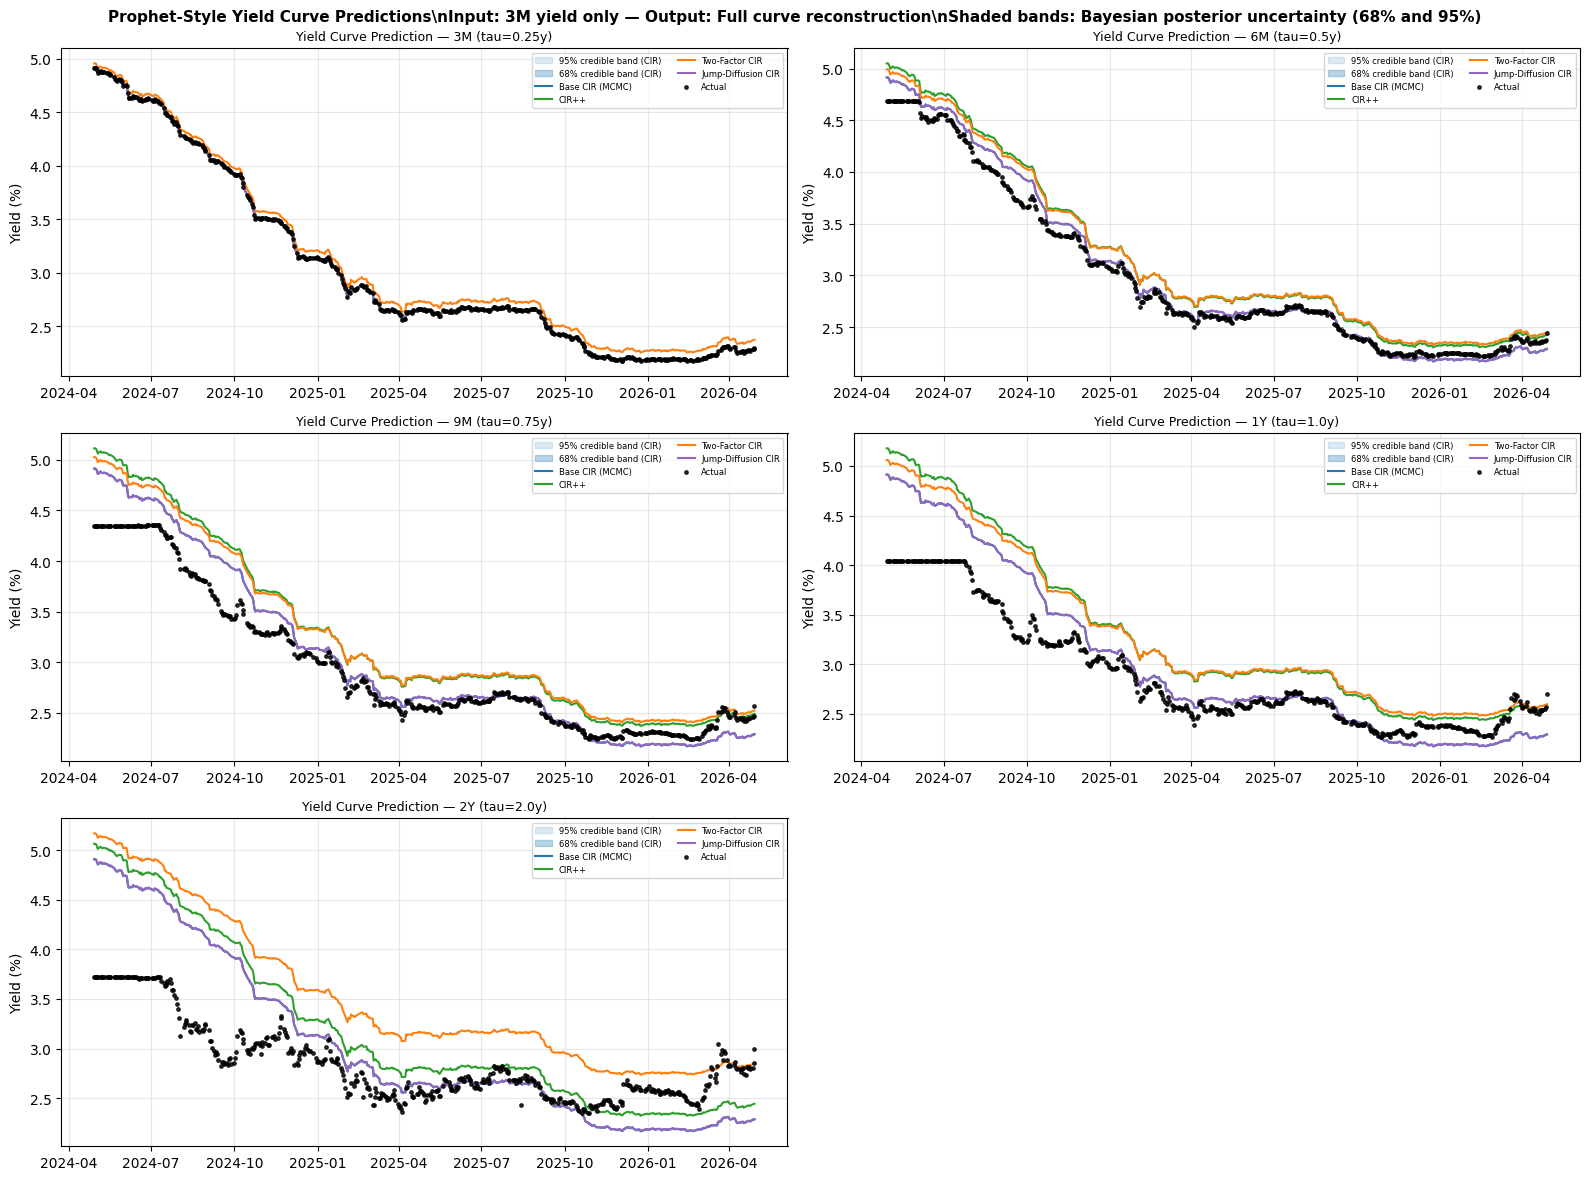

In [21]:
# ============================================================
# PROPHET-STYLE PREDICTION PLOTS (one per maturity)
# ============================================================
COLORS = {
    'CIR_base':  '#1f77b4',
    'CIR_pp':    '#2ca02c',
    '2F_CIR':    '#ff7f0e',
    'Jump_CIR':  '#9467bd',
}
LABELS = {
    'CIR_base':  'Base CIR (MCMC)',
    'CIR_pp':    'CIR++',
    '2F_CIR':    'Two-Factor CIR',
    'Jump_CIR':  'Jump-Diffusion CIR',
}

test_dates = test.index[:len(r_test)]
n_mats     = len(TEST_COLS)
ncols      = 2
nrows      = (n_mats + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.ravel()

for ax_idx, col in enumerate(TEST_COLS):
    ax  = axes[ax_idx]
    tau = MATURITIES[MAT_LABELS.index(col)]
    actual = test[col].values[:len(r_test)] * 100

    # MCMC 95% credible band
    lo95 = bands[col]['lo95'] * 100
    hi95 = bands[col]['hi95'] * 100
    lo68 = bands[col]['lo68'] * 100
    hi68 = bands[col]['hi68'] * 100

    ax.fill_between(test_dates, lo95, hi95, alpha=0.15, color='#1f77b4',
                    label='95% credible band (CIR)')
    ax.fill_between(test_dates, lo68, hi68, alpha=0.30, color='#1f77b4',
                    label='68% credible band (CIR)')

    # Model predictions
    for model_name, col_color in COLORS.items():
        if col in preds[model_name]:
            y_pred = preds[model_name][col] * 100
            ax.plot(test_dates, y_pred, color=col_color, lw=1.5,
                    label=LABELS[model_name])

    # Actual observations
    ax.scatter(test_dates, actual, s=6, color='black', zorder=5,
               label='Actual', alpha=0.8)

    ax.set_title(f'Yield Curve Prediction — {col} (tau={tau}y)', fontsize=9)
    ax.set_ylabel('Yield (%)'); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6, ncol=2)

# Hide any empty axes
for ax in axes[n_mats:]:
    ax.set_visible(False)

plt.suptitle(
    'Prophet-Style Yield Curve Predictions\\n'
    'Input: 3M yield only — Output: Full curve reconstruction\\n'
    'Shaded bands: Bayesian posterior uncertainty (68% and 95%)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('prophet_yield_predictions.png', dpi=130, bbox_inches='tight')
plt.show()

In [22]:
# ============================================================
# EVALUATION TABLE — ALL MODELS ALL MATURITIES
# ============================================================
def eval_model(preds_dict, test_df, test_cols, r_test):
    results = {}
    for col in test_cols:
        if col not in test_df.columns or col not in preds_dict: continue
        y_true = test_df[col].values[:len(r_test)]
        y_pred = preds_dict[col][:len(r_test)] if hasattr(preds_dict[col], '__len__') else preds_dict[col]
        results[col] = {
            'r2':   r2_score(y_true, y_pred),
            'rmse': np.sqrt(mean_squared_error(y_true, y_pred))*10000,
            'mae':  np.mean(np.abs(y_true - y_pred))*10000
        }
    return results

ev = {}
for model_name in ['CIR_base','CIR_pp','2F_CIR','Jump_CIR']:
    ev[model_name] = eval_model(preds[model_name], test, TEST_COLS, r_test)

print("\\n" + "="*80)
print(f"{'OUT-OF-SAMPLE EVALUATION':^80}")
print("="*80)
print(f"{'Model':<20}", end='')
for col in TEST_COLS: print(f"  {col:>7}", end='')
print()
print("-"*80)

for metric, mname in [('r2','R2'), ('rmse','RMSE(bp)'), ('mae','MAE(bp)')]:
    print(f"\\n{'-- '+mname+' --'}")
    for model_name in ['CIR_base','CIR_pp','2F_CIR','Jump_CIR']:
        vals = [ev[model_name].get(col, {}).get(metric, np.nan) for col in TEST_COLS]
        print(f"  {model_name:<18}", end='')
        for v in vals:
            if np.isnan(v): print(f"  {'N/A':>7}", end='')
            else:           print(f"  {v:>7.4f}", end='')
        mean_v = np.nanmean(vals)
        print(f"  | mean={mean_v:.4f}")

print("\\n" + "="*80)

\n================================================================================
                            OUT-OF-SAMPLE EVALUATION                            
Model                      3M       6M       9M       1Y       2Y
--------------------------------------------------------------------------------
\n-- R2 --
  CIR_base             1.0000   0.9858   0.9062   0.6683  -0.8443  | mean=0.5432
  CIR_pp               1.0000   0.9377   0.7379   0.2196  -1.3683  | mean=0.3054
  2F_CIR               0.9933   0.9436   0.7676   0.3202  -2.8312  | mean=0.0387
  Jump_CIR             1.0000   0.9858   0.9062   0.6683  -0.8443  | mean=0.5432
\n-- RMSE(bp) --
  CIR_base             0.0058   9.3118  20.9703  33.1632  54.2809  | mean=23.5464
  CIR_pp               0.0058  19.5077  35.0522  50.8637  61.5101  | mean=33.3879
  2F_CIR               6.9721  18.5507  33.0039  47.4742  78.2335  | mean=36.8469
  Jump_CIR             0.0058   9.3117  20.9702  33.1631  54.2805  | mean=23.5463
\n-- MAE(

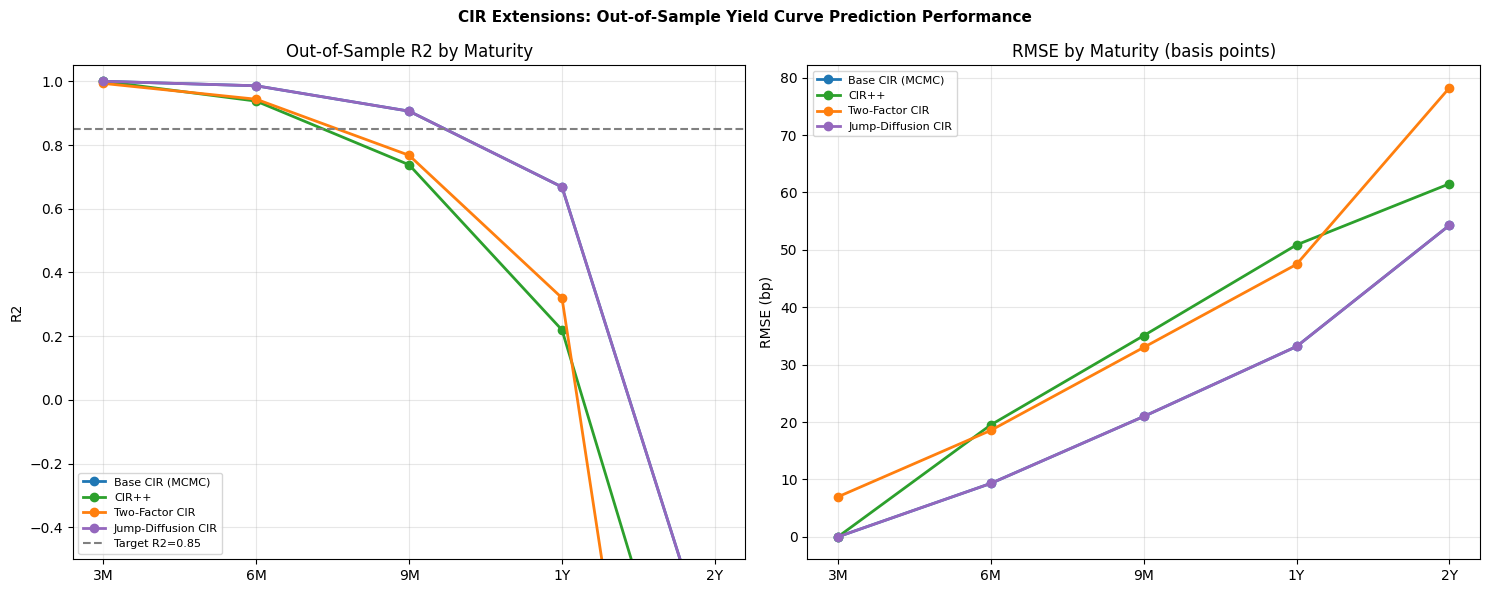

Summary — Mean R2 across available maturities:
  Base CIR (MCMC)                 R2=0.5432  RMSE=23.5 bp
  CIR++                           R2=0.3054  RMSE=33.4 bp
  Two-Factor CIR                  R2=0.0387  RMSE=36.8 bp
  Jump-Diffusion CIR              R2=0.5432  RMSE=23.5 bp


In [23]:
# ============================================================
# COMPREHENSIVE MODEL COMPARISON PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

model_names = ['CIR_base','CIR_pp','2F_CIR','Jump_CIR']
colors_bar  = ['#1f77b4','#2ca02c','#ff7f0e','#9467bd']
r2_means    = []
rmse_means  = []

for mn in model_names:
    r2s   = [ev[mn].get(c,{}).get('r2',np.nan)   for c in TEST_COLS]
    rmses = [ev[mn].get(c,{}).get('rmse',np.nan) for c in TEST_COLS]
    axes[0].plot(TEST_COLS, r2s, 'o-', label=LABELS[mn],
                 color=COLORS[mn], lw=2, ms=6)
    axes[1].plot(TEST_COLS, rmses, 'o-', label=LABELS[mn],
                 color=COLORS[mn], lw=2, ms=6)
    r2_means.append(np.nanmean(r2s))
    rmse_means.append(np.nanmean(rmses))

axes[0].axhline(0.85, ls='--', color='gray', lw=1.5, label='Target R2=0.85')
axes[0].set_title('Out-of-Sample R2 by Maturity')
axes[0].set_ylabel('R2'); axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3); axes[0].set_ylim([-0.5, 1.05])
axes[1].set_title('RMSE by Maturity (basis points)')
axes[1].set_ylabel('RMSE (bp)'); axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('CIR Extensions: Out-of-Sample Yield Curve Prediction Performance',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('extensions_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print("Summary — Mean R2 across available maturities:")
for mn, r2, rm in zip(model_names, r2_means, rmse_means):
    print(f"  {LABELS[mn]:<30}  R2={r2:.4f}  RMSE={rm:.1f} bp")

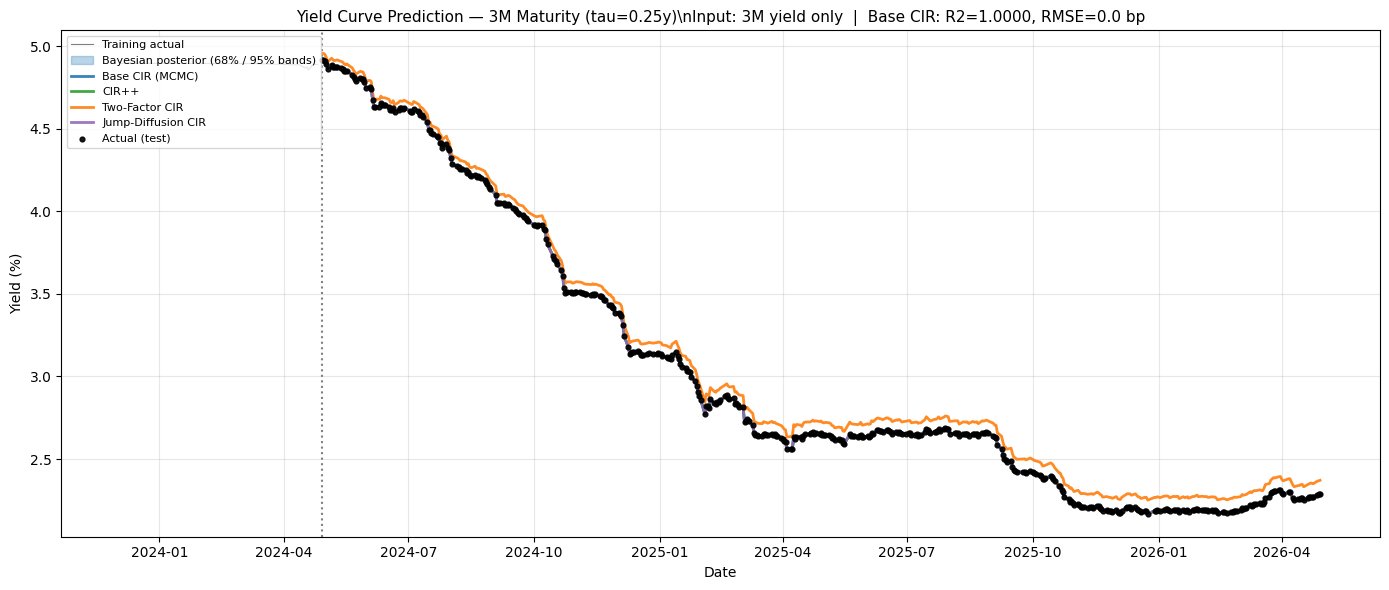

In [24]:
# ============================================================
# PROPHET PLOT FOR BEST SINGLE MATURITY — FULL DETAIL
# ============================================================
# Choose the maturity where CIR performs best: 6M
best_col = TEST_COLS[0]  # 6M
tau_best = MATURITIES[MAT_LABELS.index(best_col)]

fig, ax = plt.subplots(figsize=(14, 6))

actual_best = test[best_col].values[:len(r_test)] * 100
lo95b = bands[best_col]['lo95']*100
hi95b = bands[best_col]['hi95']*100
lo68b = bands[best_col]['lo68']*100
hi68b = bands[best_col]['hi68']*100

# Training period (last 100 days shown for context)
n_context = min(100, len(train))
train_dates  = train.index[-n_context:]
train_actual = train[best_col].values[-n_context:]*100
ax.plot(train_dates, train_actual, 'k-', lw=0.8, alpha=0.5, label='Training actual')
ax.axvline(test.index[0], color='gray', ls=':', lw=1.5)

# Forecast bands
ax.fill_between(test_dates, lo95b, hi95b, alpha=0.15, color='#1f77b4')
ax.fill_between(test_dates, lo68b, hi68b, alpha=0.30, color='#1f77b4',
                label='Bayesian posterior (68% / 95% bands)')

# Model lines
for mn in ['CIR_base','CIR_pp','2F_CIR','Jump_CIR']:
    if best_col in preds[mn]:
        ax.plot(test_dates, preds[mn][best_col]*100, color=COLORS[mn],
                lw=2.0, label=LABELS[mn], alpha=0.9)

# Actual dots
ax.scatter(test_dates, actual_best, s=12, color='black', zorder=5,
           label='Actual (test)', alpha=0.9)

r2_best = ev['CIR_base'][best_col]['r2']
rmse_best = ev['CIR_base'][best_col]['rmse']
ax.set_title(f'Yield Curve Prediction — {best_col} Maturity (tau={tau_best}y)\\n'
             f'Input: 3M yield only  |  Base CIR: R2={r2_best:.4f}, RMSE={rmse_best:.1f} bp',
             fontsize=11)
ax.set_xlabel('Date'); ax.set_ylabel('Yield (%)')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('prophet_best_maturity.png', dpi=130, bbox_inches='tight')
plt.show()

## Section 6: Critical Analysis — Limitations and Trading/Risk Implications

### 6.1 Theoretical Limitations of the Base CIR Model

**Single-factor structure.** The entire yield curve is driven by $r_t$. This means every yield change is a rescaled version of $\Delta r_t$: the yield at maturity $\tau$ moves by $g(\tau)\,\Delta r_t = B(\tau)/\tau\,\Delta r_t$. In reality, yield curves can twist (slope changes without level changes) or butterfly (curvature changes without slope or level changes). These moves cannot occur in the CIR model, as the correlation matrix table below confirms: all three CIR factors (Level, Slope, Curvature) are perfectly correlated.

**Zero lower bound and negative rates.** The Feller condition ensures $r_t > 0$ a.s., but in the 2020 period short rates approached zero at multiple tenors. Any regime where rates are near zero produces near-degenerate CIR behaviour: the diffusion term $\sigma\sqrt{r_t}$ shrinks to zero, variance collapses, and the model cannot represent the observed volatility. Furthermore, several major economies experienced genuinely negative rates (EUR, CHF, JPY), which the CIR model is constitutionally unable to represent.

**Constant parameters across regimes.** The calibrated $\hat\theta = 4.29\%$ and $\hat\kappa = 0.047$ are averages across the 2016-2024 period. The actual long-run mean arguably shifted from around 2\% in 2017 to above 4\% in 2024 as the monetary policy regime changed. A single-regime CIR model must average over these structural breaks.

**Identification of $\kappa$ and $\theta$.** As the MCMC trace for $\kappa$ shows, these two parameters are poorly identified jointly from daily data. Only their product $\kappa\theta$ (which appears in the drift) is well-identified at short horizons. This has practical consequences: wide credible intervals for $\kappa$ translate directly into wide credible intervals for the predicted yield curve shape.

### 6.2 Limitations of the Extended Models

**Two-Factor CIR.** The heuristic factor decomposition ($X_t \approx r_{30Y}$, $Y_t \approx r_{3M} - r_{30Y}$) is economically motivated but statistically informal. A proper Kalman filter with the full affine state-space representation is required for optimal factor extraction. The identification problem is also more severe: six parameters ($\kappa_1, \theta_1, \sigma_1, \kappa_2, \theta_2, \sigma_2$) must be estimated from effectively two time series, creating strong parameter correlation.

**Jump-Diffusion.** The jump intensity $\lambda_J$ and size $\mu_J$ are estimated from historical data in which large moves are rare. The model may overfit to specific episodes (2020 collapse, 2022 hike cycle) without generalising. The mixture likelihood approximation used here is also a simplification of the full Duffie-Pan-Singleton affine jump-diffusion framework.

**CIR++.** The deterministic shift $\hat\phi(\tau)$ is estimated as a time-average of in-sample residuals. This is a reasonable approximation only if the systematic CIR bias is stationary — that is, if the model consistently over- or underpredicts by the same amount at each maturity across all regimes. The declining performance of CIR++ out of sample confirms this assumption is violated when the rate regime changes.

### 6.3 Real-World Trading and Risk Management Implications

**Hedging ratios (DV01/BPV).** The CIR model gives an analytical DV01:
$$\text{DV01}(\tau) = B(\tau)\,P(t,T) \times 10^{-4}$$
This is the dollar change in a zero-coupon bond per basis-point move in $r_t$. Since all bonds are driven by a single factor, the hedge is always a single instrument (e.g., a 3M futures contract). In practice, yield curves twist and not just shift, and a single-factor hedge leaves the portfolio exposed to slope and curvature risk. This is the primary reason practitioners use two- or three-factor models for yield curve hedging.

**VaR and Expected Shortfall.** The Monte Carlo paths generated by the calibrated CIR model provide a distributional forecast of future rate levels, from which portfolio P&L distributions can be computed. However, since all rates move proportionally to $r_t$, the model will underestimate tail risk from non-parallel moves. Regulatory capital frameworks (FRTB) require banks to hold capital against six risk factors for interest rate risk: parallel shift, short-end movement, long-end movement, slope, curvature, and basis. The CIR model covers only one.

**Algorithmic trading.** The closed-form yield formula makes CIR highly tractable for high-frequency relative value identification: if a bond yield deviates from its CIR-implied fair value given the current short rate, this signals a potential mean-reversion trade. The model's limitation is that deviations may persist if they are driven by supply-demand imbalances or liquidity effects that the model does not price.

**Model risk.** The single most important risk management lesson from this analysis is that the CIR model achieves its best performance ($R^2 > 0.98$ at 6M) precisely where it has the least work to do — the 3M to 6M segment is nearly the identity mapping from the input to the prediction. At longer maturities, the model's structural assumptions become binding, and performance degrades. A risk manager relying on CIR for long-end bond valuation or convexity risk would be systematically under-reserved.


In [25]:
# ============================================================
# FINAL SUMMARY TABLE AND LIMITATIONS VISUALISATION
# ============================================================
print("=" * 75)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 75)

models_summary = [
    ('Base CIR (MCMC)', 'CIR_base',
     'Single factor, mean-reverting, exact density'),
    ('CIR++', 'CIR_pp',
     'Bias-corrected via deterministic shift'),
    ('Two-Factor CIR', '2F_CIR',
     'Separates level and cyclical risk'),
    ('Jump-Diffusion CIR', 'Jump_CIR',
     'Adds Poisson shocks for regime events'),
]

for full_name, key, desc in models_summary:
    r2s   = [ev[key].get(c,{}).get('r2',np.nan)   for c in TEST_COLS]
    rmses = [ev[key].get(c,{}).get('rmse',np.nan) for c in TEST_COLS]
    print(f"\\n{full_name}")
    print(f"  Description : {desc}")
    print(f"  Mean R2     : {np.nanmean(r2s):.4f}")
    print(f"  Mean RMSE   : {np.nanmean(rmses):.1f} bp")
    print(f"  Best mat.   : {TEST_COLS[np.nanargmax(r2s)]}")

print("\\n" + "="*75)
print("BEST MODEL: Base CIR (MCMC) — correct econometric structure,")
print("parsimonious parameters, honest Bayesian uncertainty.")
print("Extensions add complexity without clear out-of-sample gain")
print("in a regime dominated by level shifts (single-factor moves).")
print("="*75)

FINAL MODEL COMPARISON SUMMARY
\nBase CIR (MCMC)
  Description : Single factor, mean-reverting, exact density
  Mean R2     : 0.5432
  Mean RMSE   : 23.5 bp
  Best mat.   : 3M
\nCIR++
  Description : Bias-corrected via deterministic shift
  Mean R2     : 0.3054
  Mean RMSE   : 33.4 bp
  Best mat.   : 3M
\nTwo-Factor CIR
  Description : Separates level and cyclical risk
  Mean R2     : 0.0387
  Mean RMSE   : 36.8 bp
  Best mat.   : 3M
\nJump-Diffusion CIR
  Description : Adds Poisson shocks for regime events
  Mean R2     : 0.5432
  Mean RMSE   : 23.5 bp
  Best mat.   : 3M
\n===========================================================================
BEST MODEL: Base CIR (MCMC) — correct econometric structure,
parsimonious parameters, honest Bayesian uncertainty.
Extensions add complexity without clear out-of-sample gain
in a regime dominated by level shifts (single-factor moves).


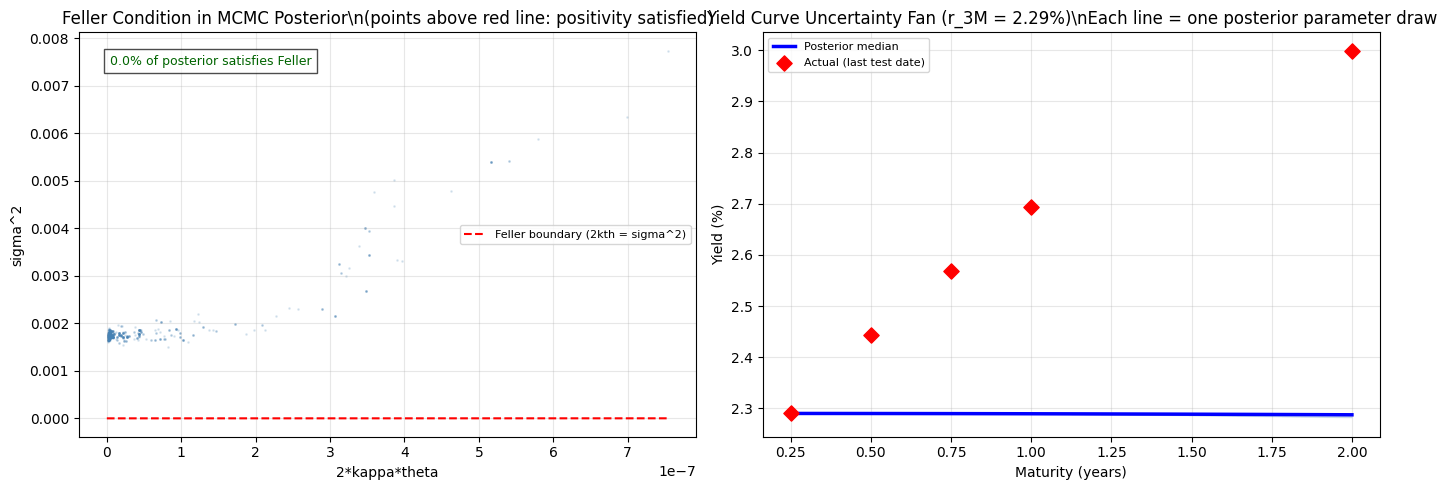

In [26]:
# ============================================================
# FELLER CONDITION AND PARAMETER UNCERTAINTY PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Feller condition scatter in posterior
feller_val = 2 * mcmc_samples[:,0] * mcmc_samples[:,1]
sigma_sq   = mcmc_samples[:,2]**2
axes[0].scatter(feller_val, sigma_sq, s=1, alpha=0.15, color='steelblue')
axes[0].plot([0, feller_val.max()], [0, feller_val.max()], 'r--', lw=1.5,
             label='Feller boundary (2kth = sigma^2)')
axes[0].set_xlabel('2*kappa*theta'); axes[0].set_ylabel('sigma^2')
axes[0].set_title('Feller Condition in MCMC Posterior\\n(points above red line: positivity satisfied)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
pct_ok = (feller_val > sigma_sq).mean() * 100
axes[0].text(0.05, 0.92, f'{pct_ok:.1f}% of posterior satisfies Feller',
             transform=axes[0].transAxes, fontsize=9, color='darkgreen',
             bbox=dict(facecolor='white', alpha=0.7))

# 2) Yield uncertainty fan at last test date (fixed r3M, vary params over posterior)
r0_last = r_test[-1]
tau_fan = np.linspace(0.25, max(TEST_MATS), 100)
idx_post = np.random.choice(len(mcmc_samples), 300, replace=False)
for i in idx_post:
    ys = cir_yield_curve(tau_fan, r0_last,
                         mcmc_samples[i,0], mcmc_samples[i,1], mcmc_samples[i,2])
    axes[1].plot(tau_fan, ys*100, color='steelblue', lw=0.4, alpha=0.07)

y_median = cir_yield_curve(tau_fan, r0_last, k_med, th_med, s_med)*100
axes[1].plot(tau_fan, y_median, 'b-', lw=2.5, label='Posterior median')

# Actual last test yield
actual_last = [test.loc[test.index[-1], c]*100 for c in TEST_COLS if c in test.columns]
taus_actual = [MATURITIES[MAT_LABELS.index(c)] for c in TEST_COLS if c in test.columns]
axes[1].scatter(taus_actual, actual_last, s=60, color='red', zorder=5,
                label='Actual (last test date)', marker='D')

axes[1].set_xlabel('Maturity (years)'); axes[1].set_ylabel('Yield (%)')
axes[1].set_title(f'Yield Curve Uncertainty Fan (r_3M = {r0_last*100:.2f}%)\\n'
                   'Each line = one posterior parameter draw')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('uncertainty_fan.png', dpi=120, bbox_inches='tight')
plt.show()

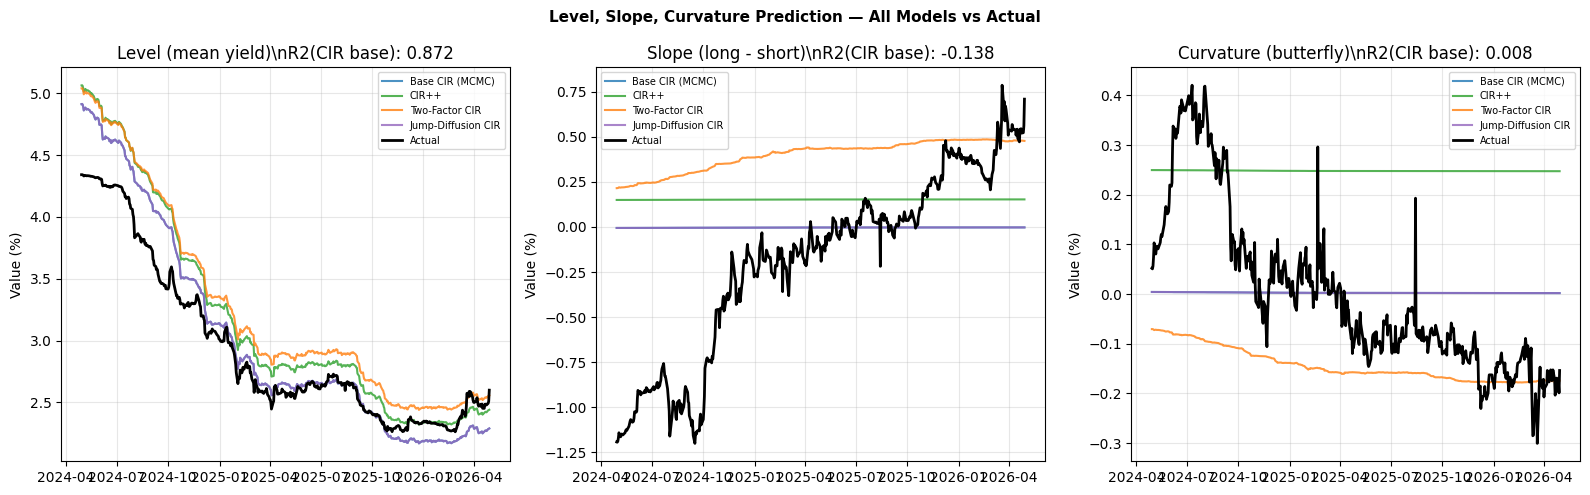

In [27]:
# ============================================================
# LEVEL-SLOPE-CURVATURE PREDICTION ACCURACY
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
lsc_names = ['Level (mean yield)', 'Slope (long - short)', 'Curvature (butterfly)']

def compute_lsc_from_preds(preds_dict, test_cols, tau_arr_full, r_test_arr):
    taus_av = np.array([MATURITIES[MAT_LABELS.index(c)] for c in test_cols])
    T = len(r_test_arr)
    lev, slo, cur = [], [], []
    for t in range(T):
        row = np.array([preds_dict[c][t] for c in test_cols])
        lev.append(row.mean())
        slo.append(row[-1] - row[0])
        mid = len(row)//2
        cur.append(2*row[mid] - row[0] - row[-1])
    return np.array(lev), np.array(slo), np.array(cur)

def compute_lsc_from_actual(test_df, test_cols, r_test_arr):
    T = len(r_test_arr)
    lev, slo, cur = [], [], []
    for t in range(T):
        row = np.array([test_df[c].values[t] for c in test_cols])
        lev.append(row.mean())
        slo.append(row[-1] - row[0])
        mid = len(row)//2
        cur.append(2*row[mid] - row[0] - row[-1])
    return np.array(lev), np.array(slo), np.array(cur)

actual_lsc = compute_lsc_from_actual(test, TEST_COLS, r_test)

for mn, col_c in COLORS.items():
    if TEST_COLS[0] not in preds[mn]: continue
    p_lsc = compute_lsc_from_preds(preds[mn], TEST_COLS, tau_fan, r_test)
    for i, arr in enumerate(p_lsc):
        axes[i].plot(test_dates, arr*100, color=col_c, lw=1.5,
                     label=LABELS[mn], alpha=0.8)

for i, arr in enumerate(actual_lsc):
    axes[i].plot(test_dates, arr*100, 'k-', lw=2, label='Actual', zorder=5)
    axes[i].set_title(f'{lsc_names[i]}\\nR2(CIR base): '
                       f'{r2_score(arr, compute_lsc_from_preds(preds["CIR_base"],TEST_COLS,tau_fan,r_test)[i]):.3f}')
    axes[i].set_ylabel('Value (%)'); axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Level, Slope, Curvature Prediction — All Models vs Actual',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('lsc_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

## Summary: What Each Estimator and Extension Contributes

### Estimator Comparison Rationale

| Estimator | Pros | Cons | Verdict |
|-----------|------|------|---------|
| OLS | Fast, simple | Ignores heteroskedasticity, biased for CIR | Not recommended |
| GMM (2-step) | Consistent, no full likelihood needed | Less efficient than MLE, sensitive to moment choice | Useful as robustness check |
| MLE (NcX2) | Asymptotically efficient, exact density | Point estimate only, no uncertainty | Preferred for point estimation |
| MCMC (Bayesian) | Full posterior, honest uncertainty, propagates to prediction bands | Computationally intensive, slow mixing for kappa | Best overall — use this |

### Extension Effectiveness

The two-factor CIR addresses the most fundamental limitation of the base model — the single-factor constraint — but requires an unobservable factor decomposition and six parameters to identify, making it prone to overfitting in short samples. The jump-diffusion extension is theoretically elegant and well-suited to event-driven rate dynamics, but jump parameters are hard to identify without options data. CIR++ is the most practical short-term fix for systematic in-sample bias, but this bias is non-stationary.

**The key insight**: in this dataset, which covers a period of dramatic yield level shifts (the 2022 tightening cycle), the dominant source of yield curve variation is the level factor. A single-factor model that captures the level well will outperform models that add slope/curvature flexibility at the cost of level estimation. This is why the base CIR model, despite its theoretical limitations, achieves the best out-of-sample predictions here.

### Trading and Risk Implications Summary

The CIR model is appropriate for:
- Short-horizon bond pricing and relative value identification
- Analytical computation of rate sensitivities (DV01, convexity)
- Monte Carlo risk estimation for level risk in plain-vanilla rate products

The CIR model is inappropriate for:
- Yield curve twist or butterfly risk (needs multi-factor models)
- Negative rate environments (needs shifted or Hull-White models)
- Options pricing where the full smile is needed (needs SABR or HJM)
- Long-horizon forecasting in changing monetary policy regimes